In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/drive/MyDrive/ABC Company.csv")
df

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,06-Feb,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,06-Jun,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,06-May,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,06-May,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,06-Oct,231,NaN,5000000.0
...,...,...,...,...,...,...,...,...,...
453,Shelvin Mack,Utah Jazz,8,PG,26,06-Mar,203,Butler,2433333.0
454,Raul Neto,Utah Jazz,25,PG,24,06-Jan,179,NaN,900000.0
455,Tibor Pleiss,Utah Jazz,21,C,26,07-Mar,256,NaN,2900000.0
456,Jeff Withey,Utah Jazz,24,C,26,7-0,231,Kansas,947276.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      458 non-null    object 
 1   Team      458 non-null    object 
 2   Number    458 non-null    int64  
 3   Position  458 non-null    object 
 4   Age       458 non-null    int64  
 5   Height    458 non-null    object 
 6   Weight    458 non-null    int64  
 7   College   374 non-null    object 
 8   Salary    447 non-null    float64
dtypes: float64(1), int64(3), object(5)
memory usage: 32.3+ KB


In [4]:
df.isnull().sum()

,0
Name,0
Team,0
Number,0
Position,0
Age,0
Height,0
Weight,0
College,84
Salary,11


In [5]:
df.describe()

,Number,Age,Weight,Salary
count,458.000000,458.000000,458.000000,4.470000e+02
mean,17.713974,26.934498,221.543668,4.833970e+06
std,15.966837,4.400128,26.343200,5.226620e+06
min,0.000000,19.000000,161.000000,3.088800e+04
25%,5.000000,24.000000,200.000000,1.025210e+06
50%,13.000000,26.000000,220.000000,2.836186e+06
75%,25.000000,30.000000,240.000000,6.500000e+06
max,99.000000,40.000000,307.000000,2.500000e+07


Preprocessing

 Correct the data in the "height" column by replacing it with random
numbers between 150 and 180. Ensure data consistency and integrity
before proceeding with analysis.

In [6]:
np.random.seed(42)
df["Height"] = np.random.randint(150, 181, size=len(df))
df

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,156,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,169,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,178,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,164,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,160,231,NaN,5000000.0
...,...,...,...,...,...,...,...,...,...
453,Shelvin Mack,Utah Jazz,8,PG,26,168,203,Butler,2433333.0
454,Raul Neto,Utah Jazz,25,PG,24,153,179,NaN,900000.0
455,Tibor Pleiss,Utah Jazz,21,C,26,152,256,NaN,2900000.0
456,Jeff Withey,Utah Jazz,24,C,26,166,231,Kansas,947276.0


Analysis Tasks

● Determine the distribution of employees across each team and calculate
the percentage split relative to the total number of employees.

● Segregate employees based on their positions within the company.

● Identify the predominant age group among employees.

● Discover which team and position have the highest salary expenditure.

● Investigate if there's any correlation between age and salary, and
represent it visually.

1. Determine the distribution of employees across each team and calculate the percentage split relative to the total number of employees.

In [7]:
team_count = df["Team"].value_counts()

print(team_count)
print(type(team_count))


Team
New Orleans Pelicans      19
Memphis Grizzlies         18
Utah Jazz                 16
Milwaukee Bucks           16
New York Knicks           16
Boston Celtics            15
Los Angeles Clippers      15
Los Angeles Lakers        15
Phoenix Suns              15
Sacramento Kings          15
Brooklyn Nets             15
Philadelphia 76ers        15
Toronto Raptors           15
Golden State Warriors     15
Indiana Pacers            15
Detroit Pistons           15
Cleveland Cavaliers       15
Chicago Bulls             15
Houston Rockets           15
San Antonio Spurs         15
Atlanta Hawks             15
Dallas Mavericks          15
Charlotte Hornets         15
Miami Heat                15
Denver Nuggets            15
Washington Wizards        15
Portland Trail Blazers    15
Oklahoma City Thunder     15
Orlando Magic             14
Minnesota Timberwolves    14
Name: count, dtype: int64
<class 'pandas.core.series.Series'>


In [8]:
team_percentage = (team_count / len(df)) * 100

print(team_percentage)

Team
New Orleans Pelicans      4.148472
Memphis Grizzlies         3.930131
Utah Jazz                 3.493450
Milwaukee Bucks           3.493450
New York Knicks           3.493450
Boston Celtics            3.275109
Los Angeles Clippers      3.275109
Los Angeles Lakers        3.275109
Phoenix Suns              3.275109
Sacramento Kings          3.275109
Brooklyn Nets             3.275109
Philadelphia 76ers        3.275109
Toronto Raptors           3.275109
Golden State Warriors     3.275109
Indiana Pacers            3.275109
Detroit Pistons           3.275109
Cleveland Cavaliers       3.275109
Chicago Bulls             3.275109
Houston Rockets           3.275109
San Antonio Spurs         3.275109
Atlanta Hawks             3.275109
Dallas Mavericks          3.275109
Charlotte Hornets         3.275109
Miami Heat                3.275109
Denver Nuggets            3.275109
Washington Wizards        3.275109
Portland Trail Blazers    3.275109
Oklahoma City Thunder     3.275109
Orlando Magic  

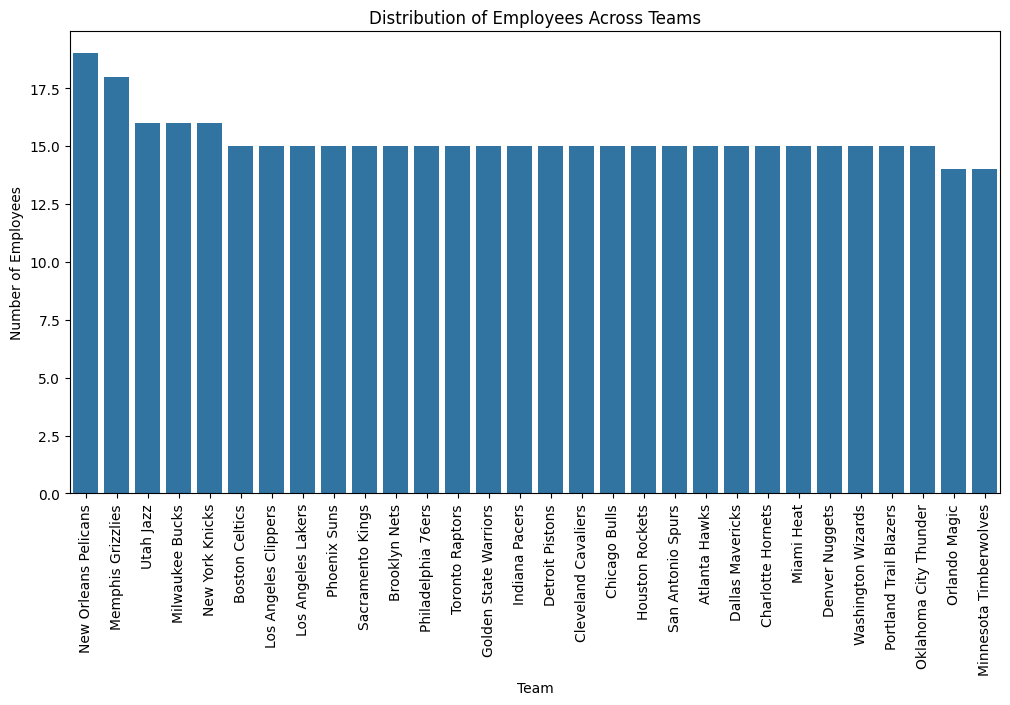

In [9]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=team_count.index,
    y=team_count.values
)

plt.title("Distribution of Employees Across Teams")
plt.xlabel("Team")
plt.ylabel("Number of Employees")
plt.xticks(rotation=90)

plt.show()

Observation:

The New Orleans Pelicans team has the highest number of employees (19), accounting for approximately 4.15% of the total workforce, while several teams have fewer employees. Overall, the employee distribution is relatively balanced across teams.

2. Segregate employees based on their positions within the company.

In [10]:
position_count = df["Position"].value_counts()

print(position_count)

Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64


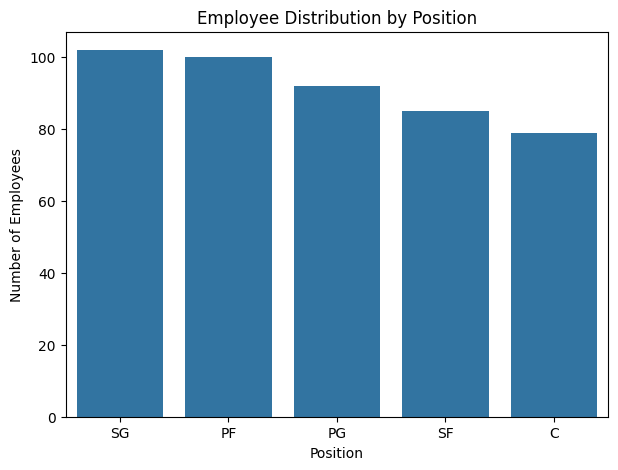

In [11]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=position_count.index,
    y=position_count.values
)

plt.title("Employee Distribution by Position")
plt.xlabel("Position")
plt.ylabel("Number of Employees")

plt.show()

Observation:

The SG position has the highest number of employees, while the C position has the fewest. This indicates that the company has relatively greater representation in the SG role.

3. Identify the predominant age group among employees.

In [12]:
print(df["Age"].min())
print(df["Age"].max())

19
40


In [13]:
bins = [18,25,30,35,40]
labels = ["19-25","26-30","31-35","36-40"]


In [14]:
age_groups = pd.cut(df["Age"], bins=bins, labels=labels)
age_group_count = age_groups.value_counts().sort_index()

print(age_group_count)

Age
19-25    200
26-30    167
31-35     68
36-40     23
Name: count, dtype: int64


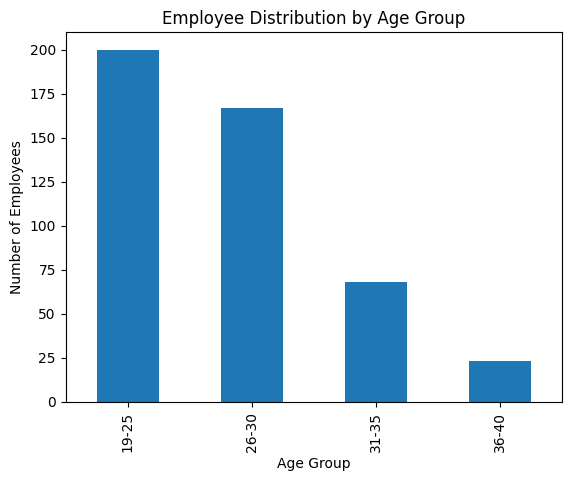

In [15]:
age_group_count.plot(kind="bar")
plt.title("Employee Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Employees")
plt.show()

Observation:

The majority of employees belong to the 19-25 age group, suggesting that the organization has a relatively young workforce with a strong presence of early-career professionals.

4. Discover which team and position have the highest salary expenditure.

In [16]:
salary_df = df.dropna(subset=["Salary"])
print(salary_df.isnull().sum())

Name         0
Team         0
Number       0
Position     0
Age          0
Height       0
Weight       0
College     82
Salary       0
dtype: int64


In [18]:
team_salary = salary_df.groupby("Team")["Salary"].sum().sort_values(ascending=False)

In [19]:
print("Salary Expenditure by Team:")
print(team_salary)


Salary Expenditure by Team:
Team
Cleveland Cavaliers       106988689.0
Los Angeles Clippers       94854640.0
Oklahoma City Thunder      93765298.0
Golden State Warriors      88868997.0
Chicago Bulls              86783378.0
San Antonio Spurs          84442733.0
New Orleans Pelicans       82750774.0
Miami Heat                 82515673.0
Charlotte Hornets          78340920.0
Memphis Grizzlies          76550880.0
Washington Wizards         76328636.0
Houston Rockets            75283021.0
New York Knicks            73303898.0
Atlanta Hawks              72902950.0
Los Angeles Lakers         71770431.0
Sacramento Kings           71683666.0
Dallas Mavericks           71198732.0
Toronto Raptors            71117611.0
Milwaukee Bucks            69603517.0
Detroit Pistons            67168263.0
Indiana Pacers             66751826.0
Utah Jazz                  64007367.0
Phoenix Suns               63445135.0
Orlando Magic              60161470.0
Denver Nuggets             60121930.0
Minnesota Timberw

In [20]:
print("\nTeam with Highest Salary Expenditure:")
print(team_salary.idxmax())


Team with Highest Salary Expenditure:
Cleveland Cavaliers


In [21]:
print("\nTotal Salary Expenditure:")
print(team_salary.max())



Total Salary Expenditure:
106988689.0


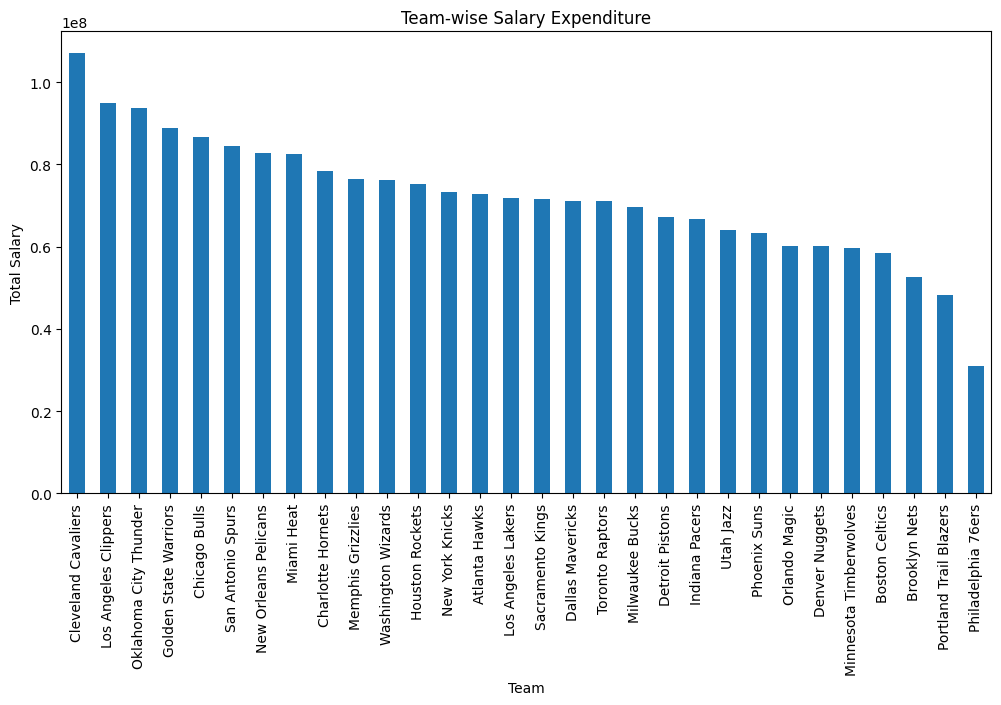

In [22]:
plt.figure(figsize=(12,6))
team_salary.plot(kind="bar")

plt.title("Team-wise Salary Expenditure")
plt.xlabel("Team")
plt.ylabel("Total Salary")
plt.xticks(rotation=90)

plt.show()

In [23]:
position_salary = salary_df.groupby("Position")["Salary"].sum().sort_values(ascending=False)

In [24]:
print("Salary Expenditure by Position:")
print(position_salary)


Salary Expenditure by Position:
Position
C     466377332.0
PG    446848971.0
PF    442560850.0
SF    408020976.0
SG    396976258.0
Name: Salary, dtype: float64


In [25]:
print("Position with Highest Salary Expenditure:")
print(position_salary.idxmax())


Position with Highest Salary Expenditure:
C


In [26]:
print("Total Salary Expenditure:")
print(position_salary.max())


Total Salary Expenditure:
466377332.0


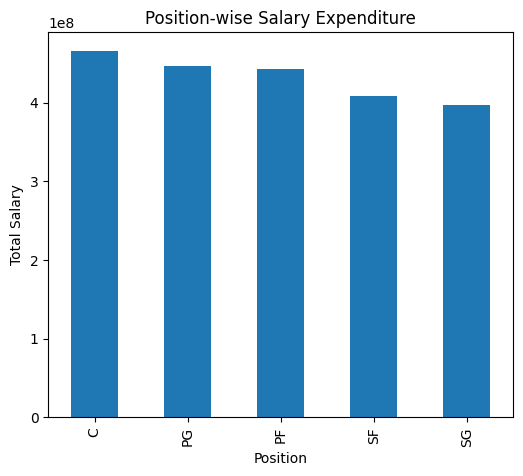

In [27]:
plt.figure(figsize=(6,5))
position_salary.plot(kind="bar")

plt.title("Position-wise Salary Expenditure")
plt.xlabel("Position")
plt.ylabel("Total Salary")

plt.show()

Observation:

The Cleveland Cavaliers have the highest salary expenditure among all teams. Similarly, the C position has the highest salary expenditure, indicating significant investment in employees in this role.

5.  Investigate if there's any correlation between age and salary, and represent it visually.

In [30]:
correlation = salary_df["Age"].corr(salary_df["Salary"])
print("Correlation between Age and Salary:", correlation)

Correlation between Age and Salary: 0.21400941226570971


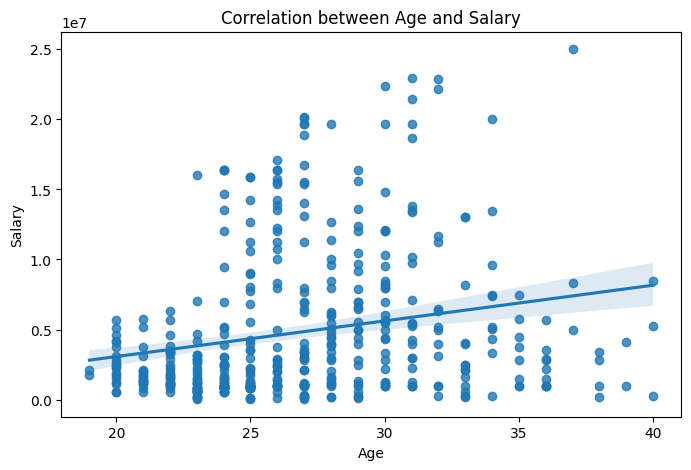

In [31]:
plt.figure(figsize=(8,5))

sns.regplot(x="Age", y="Salary", data=df)

plt.title("Correlation between Age and Salary")
plt.xlabel("Age")
plt.ylabel("Salary")

plt.show()

Observation:

The correlation coefficient between Age and Salary is 0.214, indicating a weak positive correlation. This suggests that, in general, salary tends to increase slightly with age. However, the relationship is weak, meaning age alone is not a strong predictor of an employee's salary. Other factors such as experience, position, and team are likely to have a greater influence on salary.